Initializing NUTS using jitter+adapt_diag...


Components (0: N(0,1), 1: N(b0,1)): [0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0
 0 1 0 0 0 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 0 0 0]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


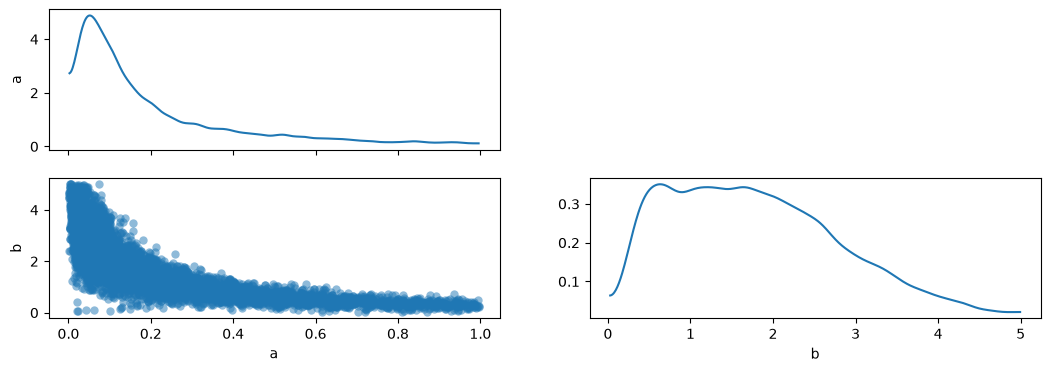

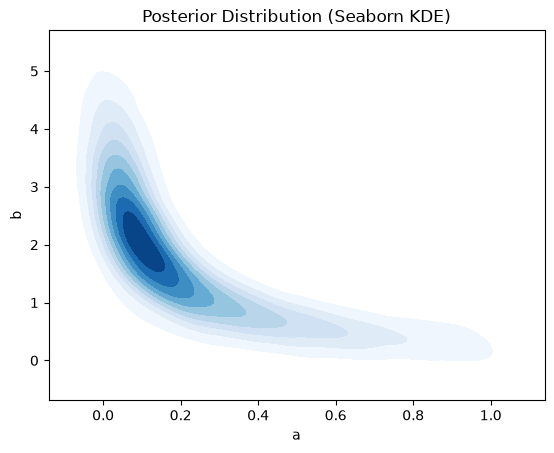

In [12]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# --- 1. 真の分布からのデータ生成 (サンプル数 n=100) ---
np.random.seed(42)
n = 100
a0, b0 = 0.5, 0.5# ケース(i)の設定

# 50%の確率で N(0,1)、50%の確率で N(b0,1) からデータを生成
components: np.ndarray = np.random.binomial(1, a0, size=n)

print("Components (0: N(0,1), 1: N(b0,1)):", components)


data = np.where(components == 0, 
                np.random.normal(0, 1, size=n), 
                np.random.normal(b0, 1, size=n))

# --- 2. PyMCによるベイズ統計モデルの定義 ---
with pm.Model() as model:
    # 事前分布の設定 (資料の式1.28に対応)
    a = pm.Uniform('a', lower=0, upper=1)
    b = pm.Uniform('b', lower=0, upper=5)
    
    # 2つの正規分布の定義
    comp_0 = pm.Normal.dist(mu=0, sigma=1)
    comp_1 = pm.Normal.dist(mu=b, sigma=1)
    
    # 重み付き混合分布 (式1.27に対応)
    w = pm.math.stack([1 - a, a])
    obs = pm.Mixture('obs', w=w, comp_dists=[comp_0, comp_1], observed=data)
    
    # --- 3. MCMCによるサンプリング（事後分布の計算） ---
    idata = pm.sample(2000, tune=1000, target_accept=0.9, return_inferencedata=True)

# --- 4. ArviZによる結果の視覚化 ---
# パラメータ a と b の事後分布をプロット
#az.plot_pair(idata, var_names=['a', 'b'], kind='kde')
az.plot_pair(idata, var_names=['a', 'b'])
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# サンプル値の取り出し（方法は上と同じです）
a_samples = idata.posterior["a"].values.flatten()
b_samples = idata.posterior["b"].values.flatten()

# seabornで塗りつぶしありの等高線を描画（cmapで青色のグラデーションを指定）
sns.kdeplot(x=a_samples, y=b_samples, fill=True, cmap="Blues")

# 軸ラベルを設定して表示
plt.xlabel("a")
plt.ylabel("b")
plt.title("Posterior Distribution (Seaborn KDE)")
plt.show()

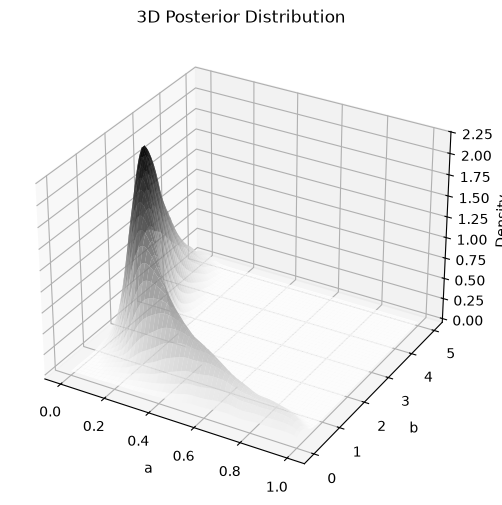

In [13]:
# ↓この1行を必ずインポート文より上に書きます
#%matplotlib tk

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pymc as pm
import arviz as az

# --- ここから下は先ほどと同じコードです ---

# 1. PyMCの推論結果(idata)からサンプルの取り出し
a_samples = idata.posterior["a"].values.flatten()
b_samples = idata.posterior["b"].values.flatten()

# 2. カーネル密度推定 (KDE) による密度の計算
values = np.vstack([a_samples, b_samples])
kde = gaussian_kde(values)

# 3. 3次元空間の床(メッシュグリッド)を作成
a_grid = np.linspace(0, 1, 100)
b_grid = np.linspace(0, 5, 100)
A, B = np.meshgrid(a_grid, b_grid)
positions = np.vstack([A.ravel(), B.ravel()])

# 各地点での山の高さを計算
Z = np.reshape(kde(positions).T, A.shape)

# 4. 3Dプロットの作成
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(A, B, Z, cmap='binary', edgecolor='none', alpha=0.8)

ax.set_xlabel('a')
ax.set_ylabel('b')
ax.set_zlabel('Density')
ax.set_title("3D Posterior Distribution")

plt.show()

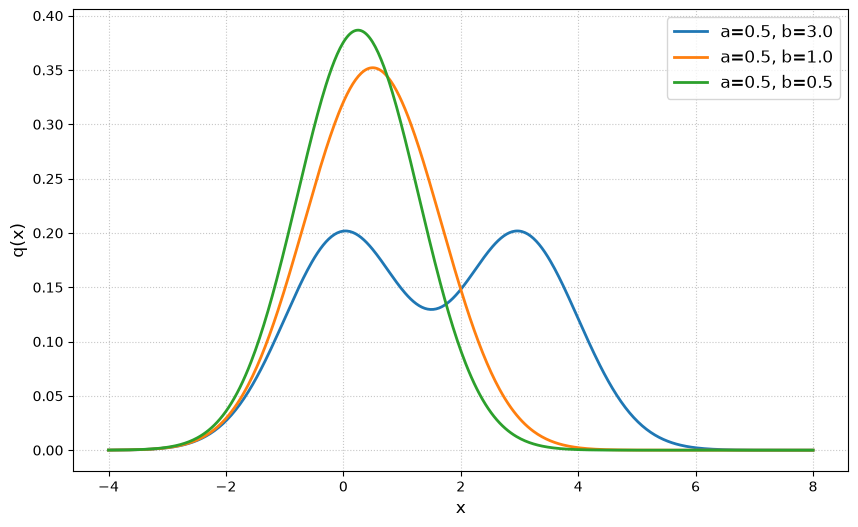

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def normal_pdf(x, mu=0.0, sigma=1.0):
    """平均mu, 分散sigma^2 (=1) の正規分布の確率密度関数 N(x)"""
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x - mu)**2)

def true_distribution(x, a, b):
    """
    混合正規分布モデル q(x) = p(x | a, b)
    式1.27: (1 - a) * N(x) + a * N(x - b)
    """
    return (1 - a) * normal_pdf(x, mu=0.0) + a * normal_pdf(x, mu=b)

# x軸の範囲を設定（-4 から 8 まで）
x = np.linspace(-4, 8, 500)

# 比較したい (a, b) の組み合わせリスト
params = [
    (0.5, 3.0),  # 教科書ケース(i): はっきり2つの山に分かれる
    (0.5, 1.0),  # 教科書ケース(ii): 山が重なってくる
    (0.5, 0.5),  # 教科書ケース(iii): ほとんど1つの山に見える
    #(0.5, 0.0),  # 特異点1: b=0 にすると完全に1つの正規分布になる
    #(0.0, 3.0),  # 特異点2: a=0 にするとbが何であれ1つの正規分布になる
]
#params = [
#    (0.5, 0.1),  # 教科書ケース(i): はっきり2つの山に分かれる
#]

# グラフの描画設定
plt.figure(figsize=(10, 6))

# それぞれのパラメータで真の分布を計算してプロット
for a, b in params:
    y = true_distribution(x, a, b)
    # 線のスタイルを少し変えて見やすくする
    if a == 0.0 or b == 0.0:
        plt.plot(x, y, label=f'a={a}, b={b} (特異点)', linestyle='--', linewidth=2.5)
    else:
        plt.plot(x, y, label=f'a={a}, b={b}', linewidth=2)

#plt.title('真の分布 $q(x) = p(x|a, b)$ の形状変化', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('q(x)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# ローカル環境用（必要に応じて %matplotlib inline 等を指定してください）
plt.show()